In [55]:
#reading data and importing lib
import numpy as numpy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [56]:
data=pd.read_csv("student_data.csv")

In [57]:
#checking data
data.sample()

,Student_ID,Gender,Study_Hours,Attendance,Previous_Score,Final_Score,Result
231,232,Male,5.8,82.4,NaN,70.9,Pass


In [58]:
data.info() 

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      300 non-null    int64  
 1   Gender          290 non-null    str    
 2   Study_Hours     288 non-null    float64
 3   Attendance      290 non-null    float64
 4   Previous_Score  288 non-null    float64
 5   Final_Score     300 non-null    float64
 6   Result          300 non-null    str    
dtypes: float64(4), int64(1), str(2)
memory usage: 16.5 KB


In [59]:
#null values
data.isnull().sum()

Student_ID         0
Gender            10
Study_Hours       12
Attendance        10
Previous_Score    12
Final_Score        0
Result             0
dtype: int64

In [60]:
data.drop_duplicates()

,Student_ID,Gender,Study_Hours,Attendance,Previous_Score,Final_Score,Result
0,1,Male,5.7,83.3,72.1,76.9,Pass
1,2,Male,4.2,80.6,77.1,66.0,Pass
2,3,Male,2.3,76.0,63.3,45.4,Pass
3,4,Female,2.2,72.3,95.1,60.5,Pass
4,5,Female,4.0,86.9,81.1,64.9,Pass
...,...,...,...,...,...,...,...
295,296,Female,5.3,91.4,45.2,62.5,Pass
296,297,Female,3.3,74.9,51.0,43.0,Pass
297,298,Male,6.4,88.5,50.4,72.2,Pass
298,299,Male,5.3,80.4,47.6,52.5,Pass


In [61]:
data.columns

Index(['Student_ID', 'Gender', 'Study_Hours', 'Attendance', 'Previous_Score',
       'Final_Score', 'Result'],
      dtype='str')

In [62]:
#outliers
#select num col

num=[]
cat=[]

for x in data.columns:
    if data[x].dtype == "str":
        cat.append(x)
    else:
        num.append(x)
print("cat", cat)
print("num", num)

cat ['Gender', 'Result']
num ['Student_ID', 'Study_Hours', 'Attendance', 'Previous_Score', 'Final_Score']


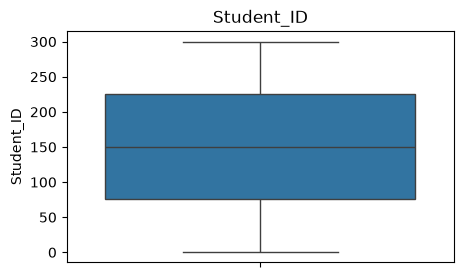

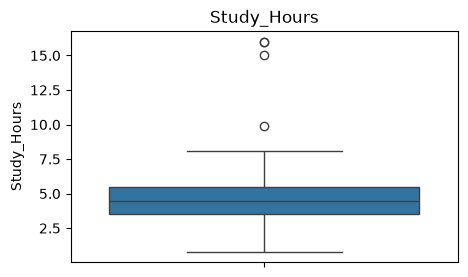

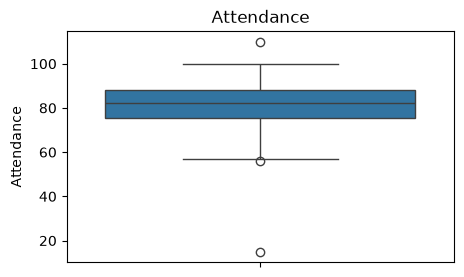

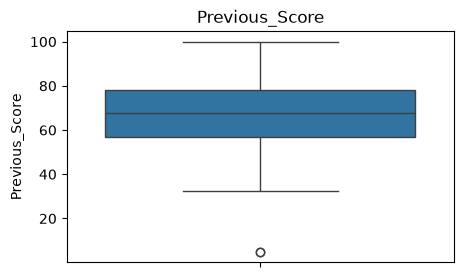

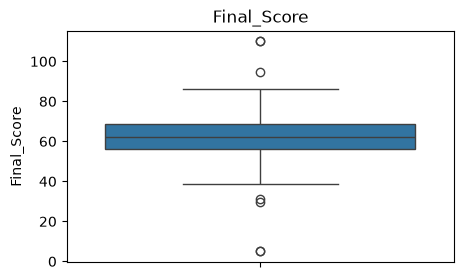

In [63]:
# box plot
for col in num:
    plt.figure(figsize=(5,3))
    sns.boxplot (data[col])
    plt.title(col)
    plt.show()

In [64]:
for col in num:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(f"{col}:{len(outliers)} outliers")

Student_ID:0 outliers
Study_Hours:4 outliers
Attendance:3 outliers
Previous_Score:2 outliers
Final_Score:7 outliers


In [65]:
Q1 = data["Study_Hours"].quantile(0.25)
Q3 = data["Study_Hours"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
data[(data["Study_Hours"] < lower) | (data["Study_Hours"] > upper)]

,Student_ID,Gender,Study_Hours,Attendance,Previous_Score,Final_Score,Result
19,20,Female,15.0,76.4,54.1,94.9,Pass
40,41,Male,9.9,93.9,88.3,82.7,Pass
79,80,Female,16.0,84.4,71.8,110.0,Pass
149,150,Female,16.0,86.0,87.3,110.0,Pass


In [66]:
data[(data["Study_Hours"] < lower) | (data["Study_Hours"] > upper)].index

Index([19, 40, 79, 149], dtype='int64')

In [69]:
data=data.drop([19,40,79,149])

In [70]:
data.sample()

,Student_ID,Gender,Study_Hours,Attendance,Previous_Score,Final_Score,Result
27,28,Female,6.2,56.7,60.4,59.6,Pass


In [72]:
data.columns

Index(['Student_ID', 'Gender', 'Study_Hours', 'Attendance', 'Previous_Score',
       'Final_Score', 'Result'],
      dtype='str')

In [73]:
data.isnull().sum()

Student_ID         0
Gender            10
Study_Hours       12
Attendance        10
Previous_Score    12
Final_Score        0
Result             0
dtype: int64

In [76]:
data["Gender"]=data["Gender"].fillna("Male")

In [77]:
data.isnull().sum()

Student_ID         0
Gender             0
Study_Hours       12
Attendance        10
Previous_Score    12
Final_Score        0
Result             0
dtype: int64